# QAOA Example (MaxCut)

This section demonstrates how to use the `cqlib-algorithm` to solve the MaxCut problem with the Quantum Approximate Optimization Algorithm (QAOA).

In [2]:
from cqlib_algorithm.problems.maxcut import MaxCut
from cqlib_algorithm.mappings.convert import maxcut_to_qubo, qubo_to_ising
from cqlib_algorithm.visualization.maxcut_plot import plot_maxcut
from cqlib_algorithm.execution import LocalRunner
from cqlib_algorithm.algorithms.qaoa import QAOASolver, QAOAConfig
from cqlib_algorithm.optimizers.options import OptimizerOptions

print("Imports ready")

Imports ready


## 1. Define the MaxCut instance

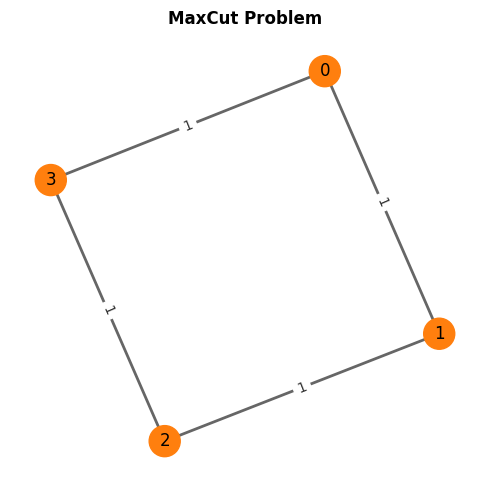

In [3]:
weights = {(0, 1): 1, (1, 2): 1, (2, 3): 1, (3, 0): 1}
mc = MaxCut(n=4, weights=weights)
plot_maxcut(n=mc.n, weights=mc.weights, partition={}, title="MaxCut Problem")

## 2. MaxCut → QUBO

In [4]:
qubo = maxcut_to_qubo(mc)
print(qubo)

========== [ QUBO ] ==========
Maximize: - 2*x_0*x_1 - 2*x_0*x_3 - 2*x_1*x_2 - 2*x_2*x_3 + 2*x_0 + 2*x_1 + 2*x_2 + 2*x_3



## 3. QUBO → Ising

In [5]:
ising = qubo_to_ising(qubo)
print(ising)

========== [ Ising Hamiltonian ] ==========
Paulis = ['IIZZ', 'ZIIZ', 'IZZI', 'ZZII'],
coeffs = [0.500, 0.500, 0.500, 0.500]
offset = -2.000



## 4. Run QAOA (LocalRunner)

In [6]:
opt_cfg = OptimizerOptions(name="spsa", options={"maxiter": 1000})
solver = QAOASolver(
    ising, runner=LocalRunner(), qaoa_cfg=QAOAConfig(reps=3, mixer="x"), opt_cfg=opt_cfg
)
res = solver.run()

[iter=  1] f=-1.900 theta=[0.004, 1.596, 1.596, -0.596, -0.596, -0.596]
[iter=  2] f=-0.986 theta=[-0.348, 1.244, 1.244, -0.244, -0.948, -0.948]
[iter=  3] f=-1.156 theta=[-0.522, 1.070, 1.418, -0.070, -0.774, -1.122]
[iter=  4] f=-1.250 theta=[-0.462, 1.010, 1.479, -0.010, -0.713, -1.182]
[iter=  5] f=-2.550 theta=[-0.796, 0.676, 1.145, -0.343, -0.379, -1.516]
[iter=  6] f=-2.538 theta=[-0.999, 0.473, 1.348, -0.141, -0.582, -1.314]
[iter=  7] f=-2.534 theta=[-1.014, 0.488, 1.363, -0.125, -0.598, -1.298]
[iter=  8] f=-2.498 theta=[-1.031, 0.505, 1.380, -0.108, -0.615, -1.281]
[iter=  9] f=-2.488 theta=[-1.045, 0.519, 1.394, -0.094, -0.629, -1.267]
[iter= 10] f=-2.232 theta=[-1.227, 0.338, 1.213, -0.276, -0.811, -1.085]
[iter= 11] f=-2.360 theta=[-1.229, 0.340, 1.215, -0.273, -0.808, -1.083]
[iter= 12] f=-2.888 theta=[-1.068, 0.179, 1.376, -0.112, -0.969, -1.244]
[iter= 13] f=-3.178 theta=[-0.941, 0.051, 1.504, -0.240, -0.841, -1.371]
[iter= 14] f=-3.312 theta=[-0.819, 0.173, 1.625, -0.

## 5. Visualization: Results

In [7]:
res.print_result()


========== [ Experiment Information ] ==========
Task ID  : 20260723110234
Shots  : 1000

========== [ Optimize Configs ] ==========
runner      : LocalRunner
qaoa_cfg    : {'reps': 3, 'mixer': 'x', 'shots': 1000, 'name': 'QAOA', 'wrap_angles': True, 'need_transpile': None, 'verbose': True}
opt_cfg    : {'name': 'spsa', 'options': {'maxiter': 1000}}

========== [ Measurement Results ] ==========
probability : {'1010': 0.501, '0101': 0.498, '1100': 0.001}


## 6. Visualization: Iteration Curve and Probability Distribution

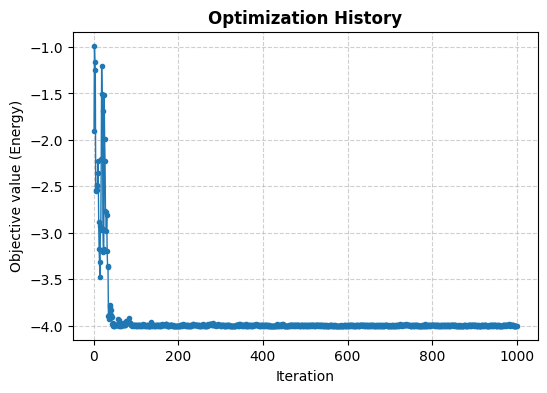

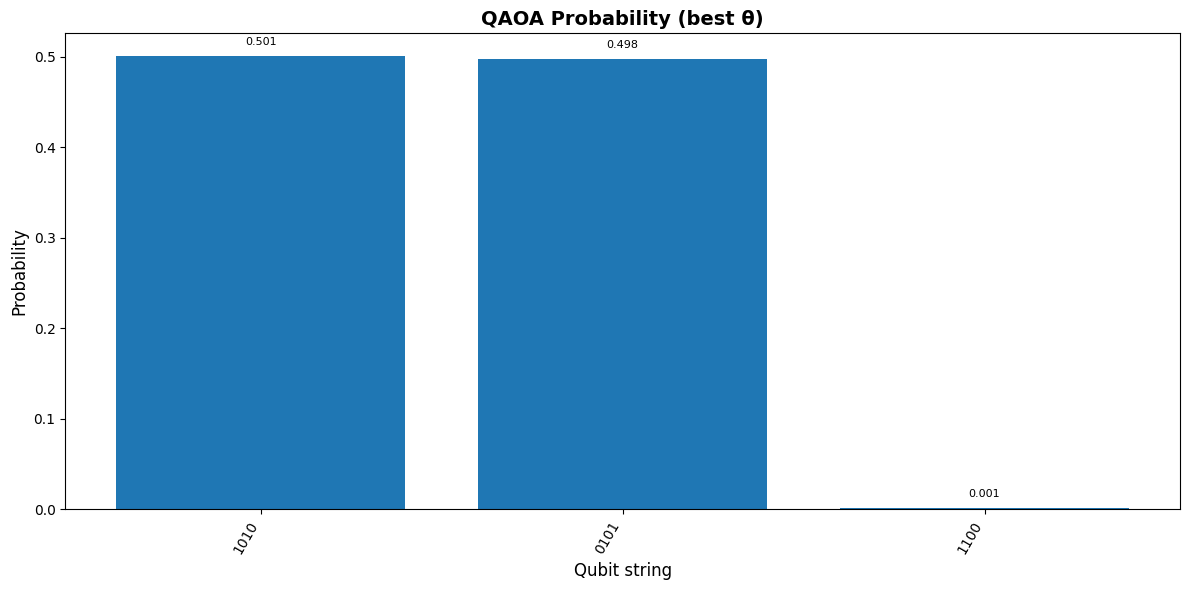

In [8]:
res.plot_history(title="Optimization History")
res.plot_probability(title="QAOA Probability (best θ)", topk=20)

## 7. Visualization: Optimal MaxCut Solution


========== [ Optimization Results ] ==========
Best gammas : [-0.637, -0.279, 2.040]
Best betas  : [-0.049, -0.982, -1.100]
Best energy : -4.000
Best Qubit string:  1010
Best solution: [0, 2]
Max-Cut value: 4.000


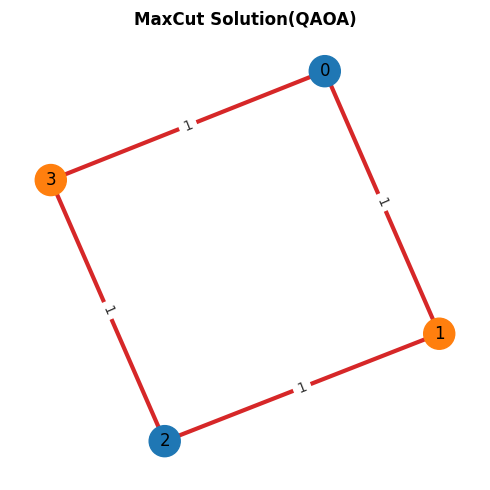

[0, 2]

In [9]:
res.plot_maxcut_solution(n=mc.n, weights=mc.weights, title="MaxCut Solution(QAOA)")

### Optional: Connect to China Telecom “TianYan” Quantum Computing Cloud Platform  
Replace `LocalRunner()` with `TianYanRunner()`:
```python
from cqlib_algorithm.execution import TianYanRunner
runner = TianYanRunner(login_key='YOUR_KEY', machine='tianyan_sw')
```
